# Lab 2: Exploratory Data Analysis (EDA) for Iris Dataset
This lab covers data loading, data quality checking, summary statistics, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load Dataset

In [2]:
df = pd.read_csv('Iris.csv')
print(df.shape) 
df.head()

(151, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


## Data Quality Check

In [3]:
df.info()
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 151 entries, 0 to 150
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             151 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB
Id               0
SepalLengthCm    1
SepalWidthCm     1
PetalLengthCm    1
PetalWidthCm     1
Species          1
dtype: int64


In [4]:
# Remove incomplete rows
ndf = df.dropna()
print('Original:', df.shape)
print('Cleaned:', ndf.shape)

Original: (151, 6)
Cleaned: (150, 6)


## Descriptive Statistics

In [5]:
ndf.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## Species Distribution

Species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


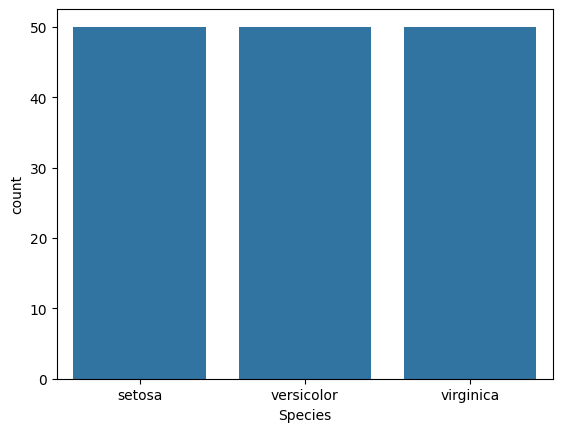

In [6]:
print(ndf['Species'].value_counts())
sns.countplot(data=ndf,x='Species')
plt.show()

## Histograms

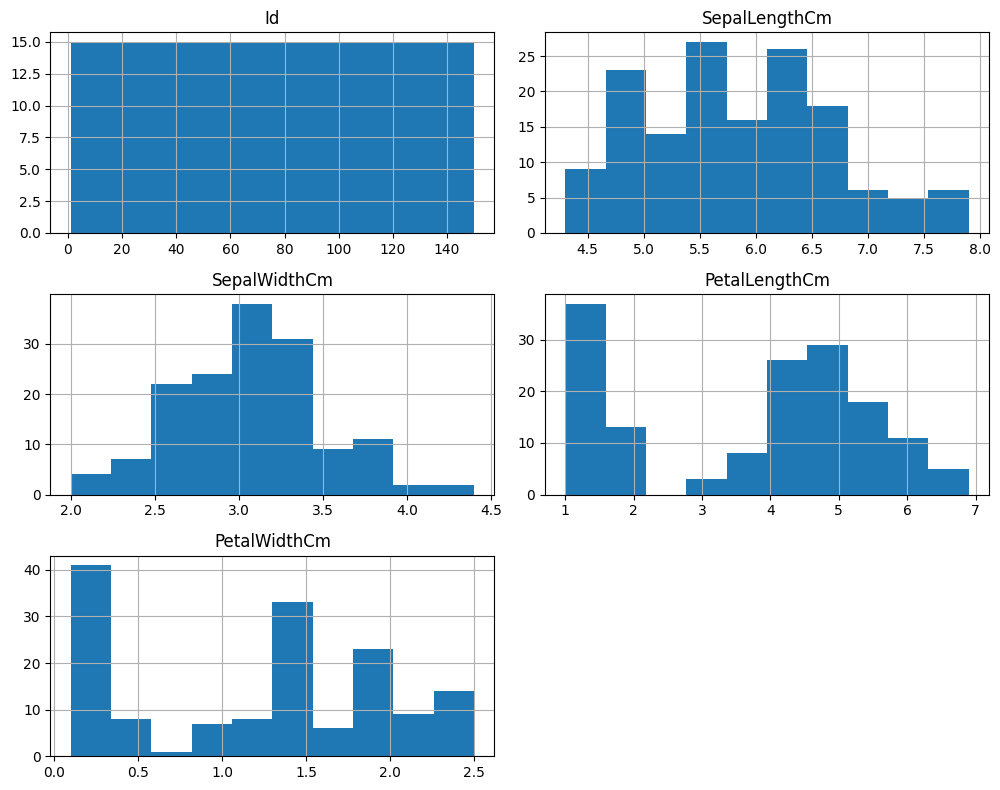

In [7]:
ndf.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

## Boxplots

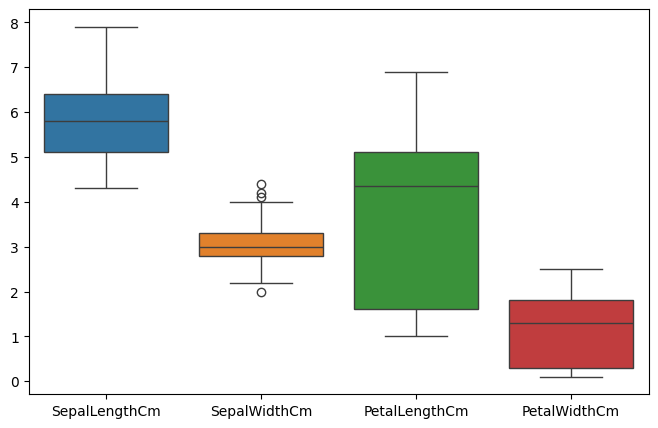

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=ndf.iloc[:,1:5])
plt.show()

## Correlation Heatmap

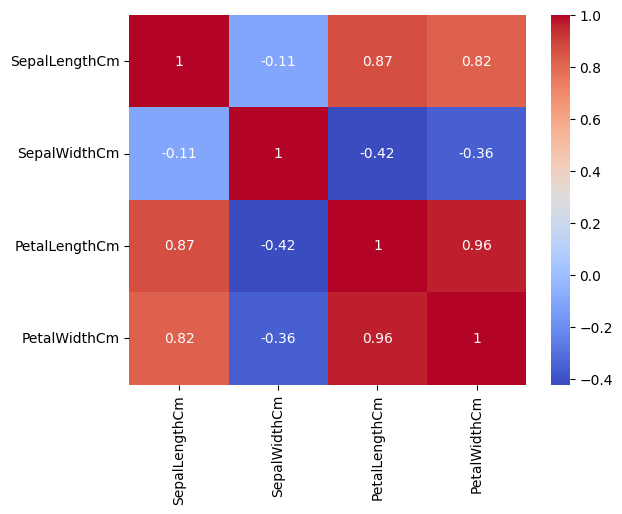

In [9]:
corr = ndf.iloc[:,1:5].corr()
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.show()

## Pairplot

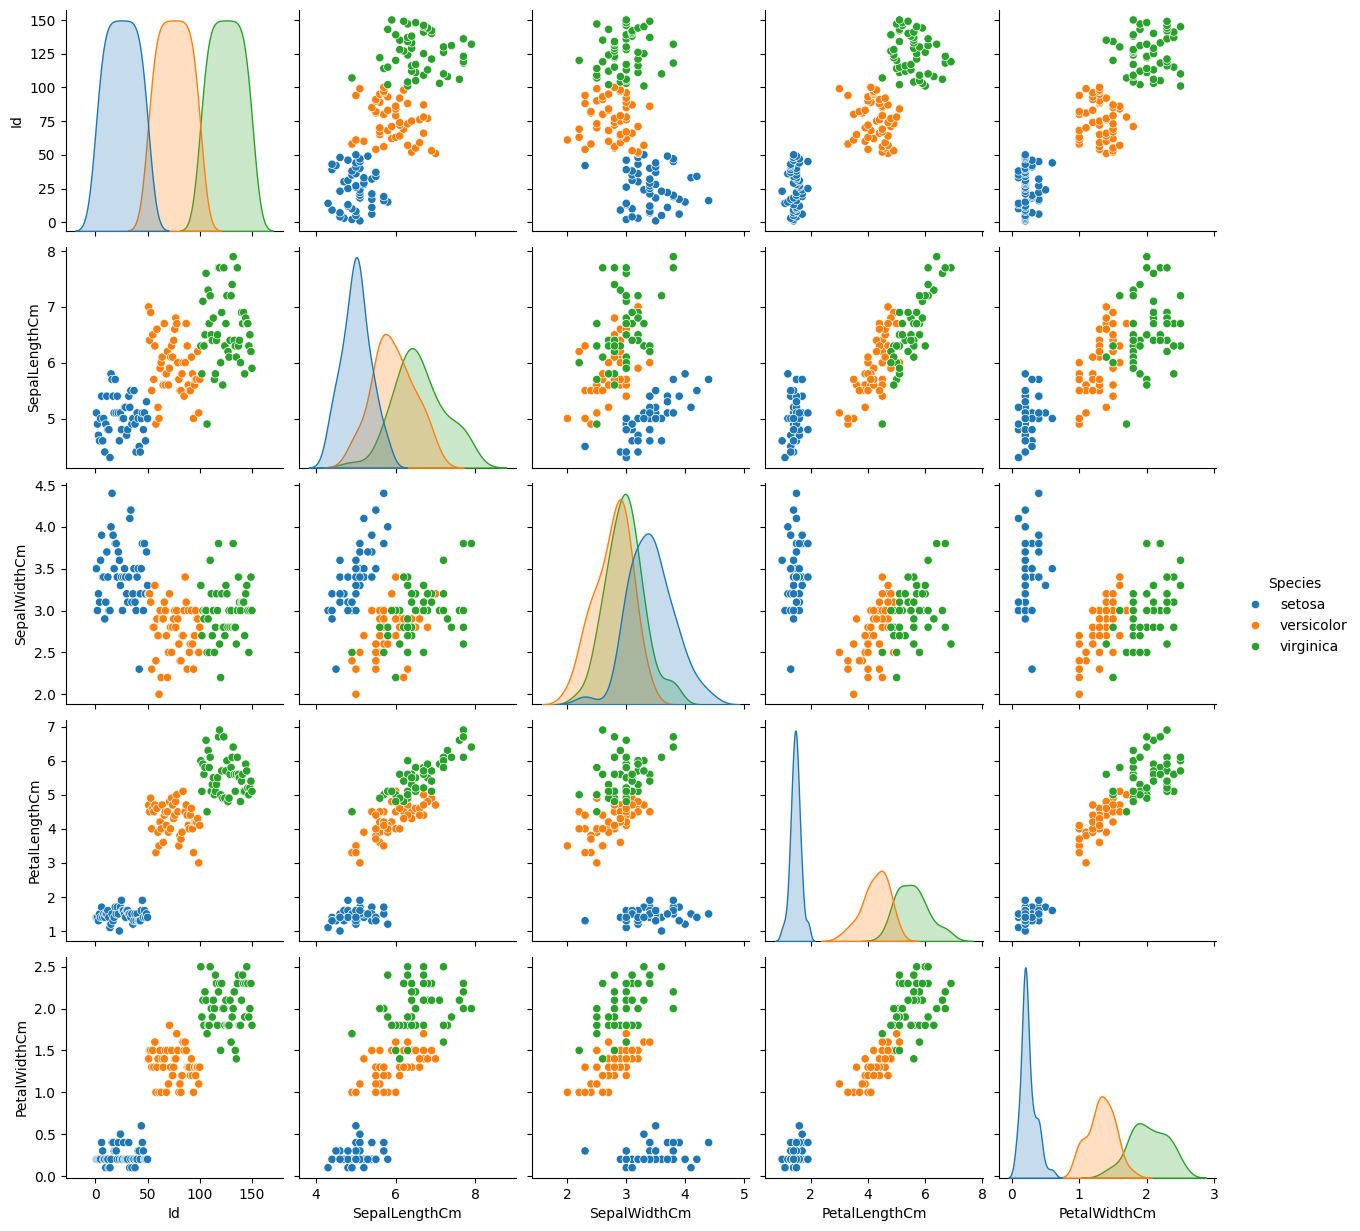

In [10]:
sns.pairplot(ndf,hue='Species')
plt.show()

## Discussion Questions
1. Are there missing values?
2. Which features are highly correlated?
3. Are there any outliers?
4. Which species are easiest to separate?

In [11]:
#Check for outliers
Q1 = ndf['SepalWidthCm'].quantile(0.25)
Q3 = ndf['SepalWidthCm'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: 2.05
Upper Bound: 4.05


In [12]:
outliers = ndf[(ndf['SepalWidthCm'] < lower_bound) | (ndf['SepalWidthCm'] > upper_bound)]
print(outliers[['Id', 'SepalWidthCm', 'Species']])

    Id  SepalWidthCm     Species
15  16           4.4      setosa
32  33           4.1      setosa
33  34           4.2      setosa
60  61           2.0  versicolor


In [13]:
outliers['Species'].value_counts()

Species
setosa        3
versicolor    1
Name: count, dtype: int64